哈特曼传感器

光路参数初始化  

In [15]:
from pprint import pprint
import numpy as np

# Lengths use SI units: m, unless the key name says px/mm/um.
optical_params = {
    "source": {
        "wavelength_m": 561.0e-9,
    },
    "camera": {
        "resolution_px": (1440, 1080),
        "pixel_pitch_m": 3.45e-6,
    },
    "microlens_array": {
        "model": "MLAS10-F15-P300-AB",
        "wavelength_range_m": (400e-9, 900e-9),
        "focal_length_m": 14.6e-3,
        "pitch_m": 300e-6,
    },
    "dm": {
        "Nact": 12,
        "DMmesh": 312,
        "DMstride": 26,
        "DMgain_m_per_count": 15.372e-9,
        "mirror_factor": 2.0,
        "pitch_m": 400e-6,
        "sigma": 1.125,
        "width": 5,
    },
    "spot_detection": {
        "threshold_relative": 0.2,
        "min_area_px": 5,
        "max_area_px": 500,
    },
    "spot_tracking": {
        "max_shift_px": 20,
        "search_radius_px": 30,
        "spot_radius_px": 5,
        "safety_margin_px": 10,
    },
    "reconstruction": {
        "n_zernike_terms": 20,
    },
}

camera_w_px, camera_h_px = optical_params["camera"]["resolution_px"]
pixel_pitch_m = optical_params["camera"]["pixel_pitch_m"]
sensor_size_m = np.array([camera_w_px, camera_h_px], dtype=float) * pixel_pitch_m

mla = optical_params["microlens_array"]
dm = optical_params["dm"]
tracking = optical_params["spot_tracking"]

min_edge_clearance_px = (
    tracking["max_shift_px"] + tracking["spot_radius_px"] + tracking["safety_margin_px"]
)

derived_params = {
    "sensor_size_mm": tuple(float(v) for v in sensor_size_m * 1e3),
    "sensor_diagonal_mm": float(np.linalg.norm(sensor_size_m) * 1e3),
    "mla_focal_length_mm": mla["focal_length_m"] * 1e3,
    "mla_pitch_um": mla["pitch_m"] * 1e6,
    "mla_lenslets_on_sensor_estimate": (
        int(sensor_size_m[0] // mla["pitch_m"]),
        int(sensor_size_m[1] // mla["pitch_m"]),
    ),
    "dm_program_aperture_mm": dm["Nact"] * dm["pitch_m"] * 1e3,
    "dm_actuator_center_span_mm": (dm["Nact"] - 1) * dm["pitch_m"] * 1e3,
    "min_edge_clearance_px": min_edge_clearance_px,
}

pprint(optical_params)
print("\nDerived parameters:")
pprint(derived_params)


{'camera': {'pixel_pitch_m': 3.45e-06, 'resolution_px': (1440, 1080)},
 'dm': {'DMgain_m_per_count': 1.5372e-08,
        'DMmesh': 312,
        'DMstride': 26,
        'Nact': 12,
        'mirror_factor': 2.0,
        'pitch_m': 0.0004,
        'sigma': 1.125,
        'width': 5},
 'microlens_array': {'focal_length_m': 0.0146,
                     'model': 'MLAS10-F15-P300-AB',
                     'pitch_m': 0.0003,
                     'wavelength_range_m': (4e-07, 9e-07)},
 'reconstruction': {'n_zernike_terms': 20},
 'source': {'wavelength_m': 5.61e-07},
 'spot_detection': {'max_area_px': 500,
                    'min_area_px': 5,
                    'threshold_relative': 0.2},
 'spot_tracking': {'max_shift_px': 20,
                   'safety_margin_px': 10,
                   'search_radius_px': 30,
                   'spot_radius_px': 5}}

Derived parameters:
{'dm_actuator_center_span_mm': 4.4,
 'dm_program_aperture_mm': 4.800000000000001,
 'min_edge_clearance_px': 35,
 'mla_focal

DM拟合相位程序

In [16]:
def dm_coordinate_grid(dm_params=None, mesh_shape=None):
    """Return x/y coordinates on the DM effective square aperture."""
    dm_params = optical_params["dm"] if dm_params is None else dm_params
    nact = int(dm_params["Nact"])
    nmesh = int(dm_params["DMmesh"])
    ny, nx = (nmesh, nmesh) if mesh_shape is None else tuple(mesh_shape)

    aperture_m = nact * float(dm_params["pitch_m"])
    dx = aperture_m / nx
    dy = aperture_m / ny
    x = (np.arange(nx, dtype=np.float64) - nx / 2 + 0.5) * dx
    y = (np.arange(ny, dtype=np.float64) - ny / 2 + 0.5) * dy
    return np.meshgrid(x, y, indexing="xy")


def dm_actuator_centers(dm_params=None):
    """Return actuator center coordinates and their row-major actuator index."""
    dm_params = optical_params["dm"] if dm_params is None else dm_params
    nact = int(dm_params["Nact"])
    pitch_m = float(dm_params["pitch_m"])
    centers_1d = (np.arange(nact, dtype=np.float64) - (nact - 1) / 2) * pitch_m
    x_centers, y_centers = np.meshgrid(centers_1d, centers_1d, indexing="xy")
    actuator_id = np.arange(nact * nact, dtype=int).reshape(nact, nact)
    return x_centers, y_centers, actuator_id


def dmstop_mask(dm_params=None):
    """Circular actuator mask used in DM_batch.py. Keep disabled for all 144 actuators."""
    dm_params = optical_params["dm"] if dm_params is None else dm_params
    nact = int(dm_params["Nact"])
    axis = np.arange(-nact / 2, nact / 2, dtype=np.float64) + 0.5
    xx, yy = np.meshgrid(axis, axis, indexing="xy")
    return (xx**2 + yy**2) <= (nact / 2 - 0.5) ** 2


def build_dm_influence_matrix(dm_params=None, mesh_shape=None, fit_mask=None, use_dmstop=False):
    """
    Build A where target_surface_m.ravel()[fit_mask] ~= A @ pressures_144.

    pressures_144 uses row-major order:
        index = actuator_row * Nact + actuator_col
    """
    dm_params = optical_params["dm"] if dm_params is None else dm_params
    nact = int(dm_params["Nact"])
    nmesh = int(dm_params["DMmesh"])
    mesh_shape = (nmesh, nmesh) if mesh_shape is None else tuple(mesh_shape)

    xx, yy = dm_coordinate_grid(dm_params=dm_params, mesh_shape=mesh_shape)
    x_centers, y_centers, _ = dm_actuator_centers(dm_params=dm_params)

    if fit_mask is None:
        valid = np.ones(mesh_shape, dtype=bool)
    else:
        valid = np.asarray(fit_mask, dtype=bool)
        if valid.shape != mesh_shape:
            raise ValueError(f"fit_mask shape {valid.shape} does not match mesh shape {mesh_shape}.")

    pitch_m = float(dm_params["pitch_m"])
    sigma_m = float(dm_params["sigma"]) * pitch_m
    dm_gain_m_per_pressure = float(dm_params["DMgain_m_per_count"])
    gaussian_factor = 4.0 * np.log(2.0)
    stop = dmstop_mask(dm_params) if use_dmstop else np.ones((nact, nact), dtype=bool)

    columns = []
    for row in range(nact):
        for col in range(nact):
            if not stop[row, col]:
                influence = np.zeros(mesh_shape, dtype=np.float64)
            else:
                r2 = (xx - x_centers[row, col]) ** 2 + (yy - y_centers[row, col]) ** 2
                influence = dm_gain_m_per_pressure * np.exp(-gaussian_factor * r2 / sigma_m**2)
            columns.append(influence[valid])

    return np.column_stack(columns)


def dm_pressures_to_surface(pressures_144, dm_params=None, mesh_shape=None, use_dmstop=False):
    """Forward DM model: 144 pressures/commands -> fitted DM surface height in meters."""
    dm_params = optical_params["dm"] if dm_params is None else dm_params
    nact = int(dm_params["Nact"])
    nmesh = int(dm_params["DMmesh"])
    mesh_shape = (nmesh, nmesh) if mesh_shape is None else tuple(mesh_shape)

    pressures = np.asarray(pressures_144, dtype=np.float64).reshape(nact * nact)
    A = build_dm_influence_matrix(
        dm_params=dm_params,
        mesh_shape=mesh_shape,
        fit_mask=np.ones(mesh_shape, dtype=bool),
        use_dmstop=use_dmstop,
    )
    return (A @ pressures).reshape(mesh_shape)


def phase_to_dm_pressures(
    target_phase_rad,
    dm_params=None,
    phase_wavelength_m=None,
    fit_mask=None,
    remove_piston=True,
    use_dmstop=False,
    rcond=1e-6,
    return_details=False,
):
    """
    Fit a 2D phase map with the 12 x 12 DM and return 144 actuator pressures.

    Input:
        target_phase_rad: 2D phase array covering the DM aperture.
            Its sampling size is flexible, for example (256, 256), (312, 312), or (512, 512).

    Output:
        pressures_144: flat array with 144 values in row-major actuator order.

    Reflection relation:
        phase = 2*pi*mirror_factor*surface_height / wavelength
        for a reflective DM, mirror_factor = 2, so phase = 4*pi*h/lambda.
    """
    dm_params = optical_params["dm"] if dm_params is None else dm_params
    nact = int(dm_params["Nact"])
    phase = np.asarray(target_phase_rad, dtype=np.float64)

    if phase.ndim != 2:
        raise ValueError(f"target_phase_rad must be a 2D phase map, got shape {phase.shape}.")
    if min(phase.shape) < nact:
        raise ValueError(
            f"target_phase_rad shape {phase.shape} is too small to fit a {nact} x {nact} DM."
        )

    wavelength_m = (
        float(optical_params["source"]["wavelength_m"])
        if phase_wavelength_m is None
        else float(phase_wavelength_m)
    )
    mirror_factor = float(dm_params.get("mirror_factor", 2.0))

    finite_mask = np.isfinite(phase)
    valid = finite_mask if fit_mask is None else (finite_mask & np.asarray(fit_mask, dtype=bool))
    if valid.shape != phase.shape:
        raise ValueError(f"fit_mask shape {valid.shape} does not match phase shape {phase.shape}.")
    if not np.any(valid):
        raise ValueError("No valid pixels are available for DM fitting.")

    phase_for_fit = phase.copy()
    if remove_piston:
        phase_for_fit[valid] -= float(np.mean(phase_for_fit[valid]))

    target_surface_m = phase_for_fit * wavelength_m / (2.0 * np.pi * mirror_factor)
    A = build_dm_influence_matrix(
        dm_params=dm_params,
        mesh_shape=phase.shape,
        fit_mask=valid,
        use_dmstop=use_dmstop,
    )
    b = target_surface_m[valid]
    pressures_144, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=rcond)

    if not return_details:
        return pressures_144

    fitted_surface_m = dm_pressures_to_surface(
        pressures_144,
        dm_params=dm_params,
        mesh_shape=phase.shape,
        use_dmstop=use_dmstop,
    )
    fitted_phase_rad = fitted_surface_m * (2.0 * np.pi * mirror_factor) / wavelength_m
    residual_phase_rad = np.full_like(phase, np.nan, dtype=np.float64)
    residual_phase_rad[valid] = phase_for_fit[valid] - fitted_phase_rad[valid]

    details = {
        "pressure_grid": pressures_144.reshape(nact, nact),
        "fitted_surface_m": fitted_surface_m,
        "fitted_phase_rad": fitted_phase_rad,
        "residual_phase_rad": residual_phase_rad,
        "rms_residual_phase_rad": float(np.sqrt(np.mean(residual_phase_rad[valid] ** 2))),
        "rank": int(rank),
        "singular_values": singular_values,
        "valid_pixel_count": int(np.count_nonzero(valid)),
        "phase_wavelength_m": wavelength_m,
    }
    return pressures_144, details


# Example usage:
# xx_dm, yy_dm = dm_coordinate_grid(mesh_shape=(512, 512))
# target_phase_rad = 0.5 * (2 * (xx_dm / (2.4e-3))**2 - 1)  # replace with your measured/target phase
# pressures_144, fit_details = phase_to_dm_pressures(target_phase_rad, return_details=True)
# fit_details["pressure_grid"].shape, pressures_144.shape, fit_details["rms_residual_phase_rad"]


随机生成zernike系数，生成zernike系数对应的图像

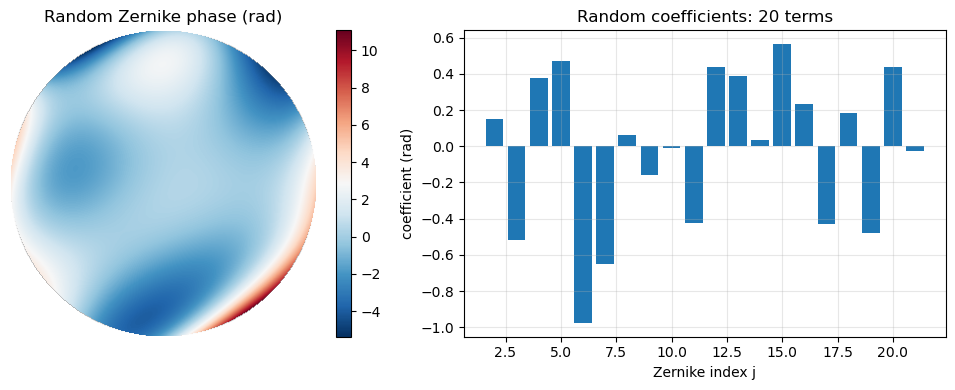

[{'j': 2, 'n': 1, 'm': 1, 'coeff_rad': 0.15235853987721568},
 {'j': 3, 'n': 2, 'm': -2, 'coeff_rad': -0.5199920531202478},
 {'j': 4, 'n': 2, 'm': 0, 'coeff_rad': 0.3752255979032286},
 {'j': 5, 'n': 2, 'm': 2, 'coeff_rad': 0.47028235819560693},
 {'j': 6, 'n': 3, 'm': -3, 'coeff_rad': -0.9755175943269182}]

In [17]:
import matplotlib.pyplot as plt
from math import comb, sqrt

# Manual controls.
n_zernike_terms = 20
zernike_grid_size = int(optical_params["dm"]["DMmesh"])
coeff_std_rad = 0.5
random_seed = 42
include_piston = False


def j_to_mn(j):
    n = int(np.ceil((-3.0 + np.sqrt(9.0 + 8.0 * j)) / 2.0))
    m = int(2 * j - n * (n + 2))
    return m, n


def radial_polynomial(n, m_abs, rho):
    if (n - m_abs) % 2:
        return np.zeros_like(rho)
    radial = np.zeros_like(rho)
    for s in range((n - m_abs) // 2 + 1):
        c = (-1) ** s * comb(n - s, s) * comb(n - 2 * s, (n - m_abs) // 2 - s)
        radial += c * rho ** (n - 2 * s)
    return radial


def zernike_mode(j, rho, theta):
    m, n = j_to_mn(j)
    radial = radial_polynomial(n, abs(m), rho)
    if m == 0:
        return sqrt(n + 1) * radial
    if m > 0:
        return sqrt(2 * (n + 1)) * radial * np.cos(m * theta)
    return sqrt(2 * (n + 1)) * radial * np.sin(abs(m) * theta)


def random_zernike_phase(n_terms=20, grid_size=312, coeff_std_rad=0.5, seed=42, include_piston=False):
    axis = np.linspace(-1.0, 1.0, grid_size)
    xx, yy = np.meshgrid(axis, axis, indexing="xy")
    rho = np.sqrt(xx**2 + yy**2)
    theta = np.arctan2(yy, xx)
    pupil_mask = rho <= 1.0

    first_j = 1 if include_piston else 2
    zernike_indices = np.arange(first_j, first_j + n_terms)
    coeffs_rad = np.random.default_rng(seed).normal(0.0, coeff_std_rad, size=n_terms)

    phase_rad = np.zeros_like(rho)
    coeff_table = []
    for j, coeff in zip(zernike_indices, coeffs_rad):
        m, n = j_to_mn(int(j))
        phase_rad[pupil_mask] += coeff * zernike_mode(int(j), rho, theta)[pupil_mask]
        coeff_table.append({"j": int(j), "n": int(n), "m": int(m), "coeff_rad": float(coeff)})

    phase_rad[~pupil_mask] = np.nan
    return phase_rad, coeff_table


zernike_phase_rad, zernike_coeffs = random_zernike_phase(
    n_terms=n_zernike_terms,
    grid_size=zernike_grid_size,
    coeff_std_rad=coeff_std_rad,
    seed=random_seed,
    include_piston=include_piston,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(zernike_phase_rad, cmap="RdBu_r", origin="lower")
axes[0].set_title("Random Zernike phase (rad)")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].bar([c["j"] for c in zernike_coeffs], [c["coeff_rad"] for c in zernike_coeffs])
axes[1].set_title(f"Random coefficients: {n_zernike_terms} terms")
axes[1].set_xlabel("Zernike index j")
axes[1].set_ylabel("coefficient (rad)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

zernike_coeffs[:5]


使用DM拟合上面的zernike系数，并展示DM的拟合效果和各个平面的压力。

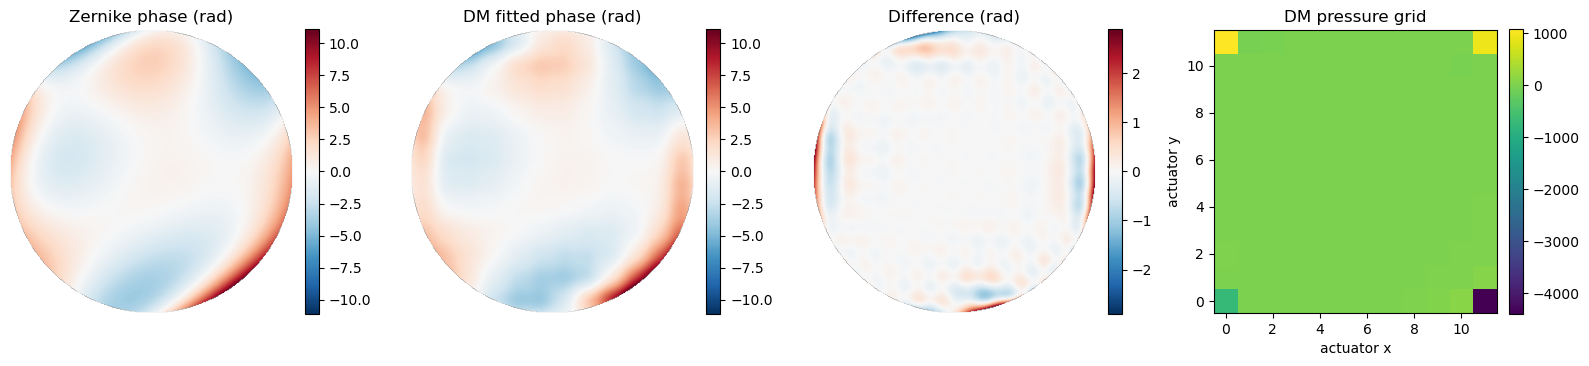

RMS residual phase: 0.2634 rad
pressure shape: (144,), pressure grid shape: (12, 12)


In [18]:
pupil_mask = np.isfinite(zernike_phase_rad)

dm_pressures_144, dm_fit = phase_to_dm_pressures(
    zernike_phase_rad,
    fit_mask=pupil_mask,
    remove_piston=True,
    return_details=True,
)

target_phase_for_compare = zernike_phase_rad.copy()
target_phase_for_compare[pupil_mask] -= np.mean(target_phase_for_compare[pupil_mask])

dm_fitted_phase_rad = dm_fit["fitted_phase_rad"].copy()
dm_fitted_phase_rad[~pupil_mask] = np.nan

phase_difference_rad = target_phase_for_compare - dm_fitted_phase_rad
phase_difference_rad[~pupil_mask] = np.nan

vmax = np.nanmax(np.abs(target_phase_for_compare))
diff_vmax = np.nanmax(np.abs(phase_difference_rad))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(target_phase_for_compare, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
axes[0].set_title("Zernike phase (rad)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dm_fitted_phase_rad, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
axes[1].set_title("DM fitted phase (rad)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(phase_difference_rad, cmap="RdBu_r", origin="lower", vmin=-diff_vmax, vmax=diff_vmax)
axes[2].set_title("Difference (rad)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(dm_fit["pressure_grid"], cmap="viridis", origin="lower")
axes[3].set_title("DM pressure grid")
axes[3].set_xlabel("actuator x")
axes[3].set_ylabel("actuator y")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"RMS residual phase: {dm_fit['rms_residual_phase_rad']:.4f} rad")
print(f"pressure shape: {dm_pressures_144.shape}, pressure grid shape: {dm_fit['pressure_grid'].shape}")


下面完成光的仿真程序，实际程序是会用实际图像代替

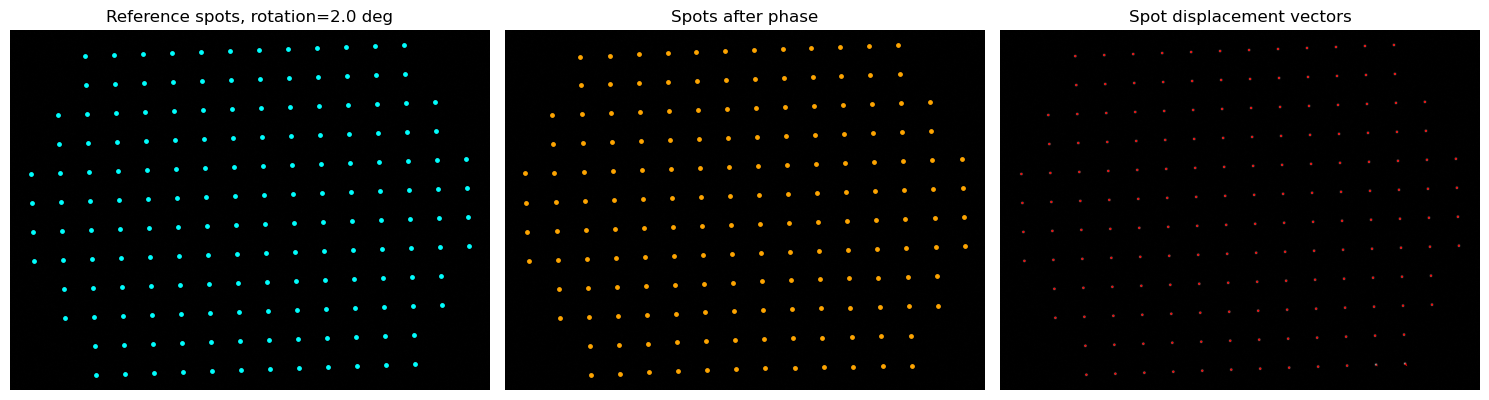

lenslet grid shape: (12, 16), valid spots: 168
mean shift: 1.448 px
max shift: 10.929 px


In [19]:
import matplotlib.pyplot as plt

# Geometric Shack-Hartmann simulation controls.
mla_rotation_deg = 2.0
spot_sigma_px = 2.0
spot_amplitude = 1.0
image_noise_std = 0.01
simulation_seed = 1


def make_rotated_lenslet_grid(rotation_deg=0.0):
    camera = optical_params["camera"]
    mla = optical_params["microlens_array"]
    tracking = optical_params["spot_tracking"]

    width_px, height_px = camera["resolution_px"]
    pitch_px = mla["pitch_m"] / camera["pixel_pitch_m"]
    margin_px = tracking["safety_margin_px"] + tracking["spot_radius_px"]

    nx = int((width_px - 2 * margin_px) // pitch_px)
    ny = int((height_px - 2 * margin_px) // pitch_px)

    cols = np.arange(nx) - (nx - 1) / 2
    rows = np.arange(ny) - (ny - 1) / 2
    gx, gy = np.meshgrid(cols * pitch_px, rows * pitch_px, indexing="xy")

    angle = np.deg2rad(rotation_deg)
    x_rot = gx * np.cos(angle) - gy * np.sin(angle)
    y_rot = gx * np.sin(angle) + gy * np.cos(angle)

    points_px = np.column_stack([
        x_rot.ravel() + width_px / 2,
        y_rot.ravel() + height_px / 2,
    ])
    lenslet_xy_m = (points_px - np.array([[width_px / 2, height_px / 2]])) * camera["pixel_pitch_m"]
    lenslet_id = np.arange(points_px.shape[0])
    return points_px, lenslet_xy_m, lenslet_id, (ny, nx)


def bilinear_sample(image, x_float, y_float):
    h, w = image.shape
    x0 = np.floor(x_float).astype(int)
    y0 = np.floor(y_float).astype(int)
    x1 = x0 + 1
    y1 = y0 + 1

    valid = (x0 >= 0) & (x1 < w) & (y0 >= 0) & (y1 < h)
    out = np.full_like(x_float, np.nan, dtype=np.float64)
    if not np.any(valid):
        return out, valid

    xv = x_float[valid]
    yv = y_float[valid]
    x0v = x0[valid]
    x1v = x1[valid]
    y0v = y0[valid]
    y1v = y1[valid]

    wx = xv - x0v
    wy = yv - y0v
    out[valid] = (
        (1 - wx) * (1 - wy) * image[y0v, x0v]
        + wx * (1 - wy) * image[y0v, x1v]
        + (1 - wx) * wy * image[y1v, x0v]
        + wx * wy * image[y1v, x1v]
    )
    return out, valid


def phase_slope_at_points(phase_rad, xy_m):
    dm = optical_params["dm"]
    wavelength_m = optical_params["source"]["wavelength_m"]
    aperture_m = dm["Nact"] * dm["pitch_m"]
    ny, nx = phase_rad.shape
    dx_m = aperture_m / nx
    dy_m = aperture_m / ny

    phase_clean = np.nan_to_num(phase_rad, nan=0.0)
    dphi_dy, dphi_dx = np.gradient(phase_clean, dy_m, dx_m)

    x_pix = xy_m[:, 0] / dx_m + nx / 2 - 0.5
    y_pix = xy_m[:, 1] / dy_m + ny / 2 - 0.5

    dphi_dx_s, valid_x = bilinear_sample(dphi_dx, x_pix, y_pix)
    dphi_dy_s, valid_y = bilinear_sample(dphi_dy, x_pix, y_pix)

    rho = np.sqrt(xy_m[:, 0] ** 2 + xy_m[:, 1] ** 2) / (aperture_m / 2)
    valid = valid_x & valid_y & (rho <= 0.98)

    slope_x = wavelength_m / (2 * np.pi) * dphi_dx_s
    slope_y = wavelength_m / (2 * np.pi) * dphi_dy_s
    slope_x[~valid] = np.nan
    slope_y[~valid] = np.nan
    return slope_x, slope_y, valid


def render_spot_image(points_px, valid=None, image_shape=None, sigma_px=2.0, amplitude=1.0, noise_std=0.0, seed=None):
    camera = optical_params["camera"]
    width_px, height_px = camera["resolution_px"]
    if image_shape is None:
        image_shape = (height_px, width_px)
    if valid is None:
        valid = np.ones(points_px.shape[0], dtype=bool)

    image = np.zeros(image_shape, dtype=np.float64)
    radius = int(np.ceil(4 * sigma_px))

    for (x, y), ok in zip(points_px, valid):
        if not ok or not np.isfinite(x) or not np.isfinite(y):
            continue
        x0 = max(0, int(np.floor(x)) - radius)
        x1 = min(image_shape[1], int(np.floor(x)) + radius + 1)
        y0 = max(0, int(np.floor(y)) - radius)
        y1 = min(image_shape[0], int(np.floor(y)) + radius + 1)
        if x0 >= x1 or y0 >= y1:
            continue
        xx, yy = np.meshgrid(np.arange(x0, x1), np.arange(y0, y1), indexing="xy")
        image[y0:y1, x0:x1] += amplitude * np.exp(-0.5 * ((xx - x) ** 2 + (yy - y) ** 2) / sigma_px**2)

    if noise_std > 0:
        image += np.random.default_rng(seed).normal(0.0, noise_std, size=image.shape)
    return np.clip(image, 0.0, None)


reference_points_px, lenslet_xy_m, lenslet_id, lenslet_grid_shape = make_rotated_lenslet_grid(mla_rotation_deg)
slope_x, slope_y, spot_valid = phase_slope_at_points(zernike_phase_rad, lenslet_xy_m)

f_mla = optical_params["microlens_array"]["focal_length_m"]
pixel_pitch_m = optical_params["camera"]["pixel_pitch_m"]
spot_shift_px = np.column_stack([f_mla * slope_x / pixel_pitch_m, f_mla * slope_y / pixel_pitch_m])
measurement_points_px = reference_points_px + np.nan_to_num(spot_shift_px, nan=0.0)

reference_image_sim = render_spot_image(
    reference_points_px,
    valid=spot_valid,
    sigma_px=spot_sigma_px,
    amplitude=spot_amplitude,
    noise_std=image_noise_std,
    seed=simulation_seed,
)
measurement_image_sim = render_spot_image(
    measurement_points_px,
    valid=spot_valid,
    sigma_px=spot_sigma_px,
    amplitude=spot_amplitude,
    noise_std=image_noise_std,
    seed=simulation_seed + 1,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(reference_image_sim, cmap="gray", origin="lower")
axes[0].scatter(reference_points_px[spot_valid, 0], reference_points_px[spot_valid, 1], s=6, c="cyan")
axes[0].set_title(f"Reference spots, rotation={mla_rotation_deg} deg")
axes[0].axis("off")

axes[1].imshow(measurement_image_sim, cmap="gray", origin="lower")
axes[1].scatter(measurement_points_px[spot_valid, 0], measurement_points_px[spot_valid, 1], s=6, c="orange")
axes[1].set_title("Spots after phase")
axes[1].axis("off")

axes[2].imshow(reference_image_sim, cmap="gray", origin="lower")
axes[2].quiver(
    reference_points_px[spot_valid, 0],
    reference_points_px[spot_valid, 1],
    spot_shift_px[spot_valid, 0],
    spot_shift_px[spot_valid, 1],
    color="red",
    angles="xy",
    scale_units="xy",
    scale=1,
)
axes[2].set_title("Spot displacement vectors")
axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"lenslet grid shape: {lenslet_grid_shape}, valid spots: {np.count_nonzero(spot_valid)}")
print(f"mean shift: {np.nanmean(np.linalg.norm(spot_shift_px[spot_valid], axis=1)):.3f} px")
print(f"max shift: {np.nanmax(np.linalg.norm(spot_shift_px[spot_valid], axis=1)):.3f} px")


根据图像预测zernike系数并进行比较

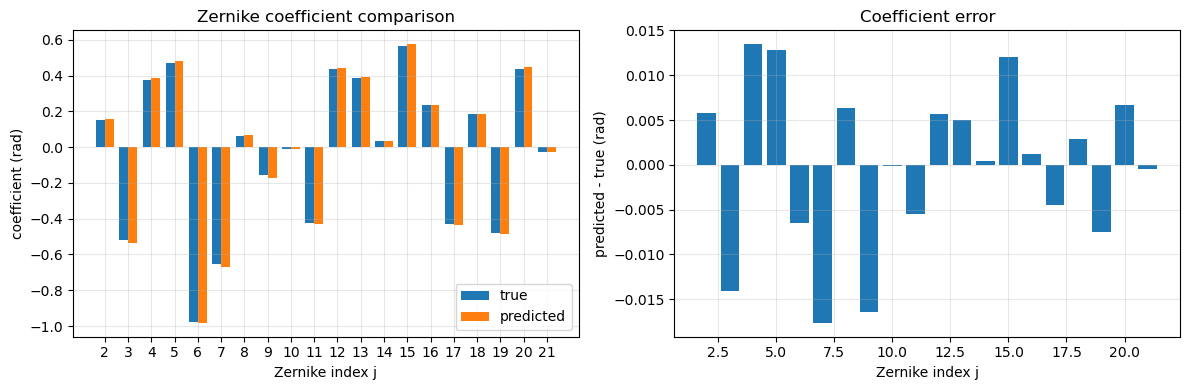

coefficient RMS error: 0.008946 rad
valid spots used: 168


In [20]:
def build_zernike_slope_matrix(zernike_indices, xy_m, valid_mask, grid_shape):
    dm = optical_params["dm"]
    wavelength_m = optical_params["source"]["wavelength_m"]
    aperture_m = dm["Nact"] * dm["pitch_m"]
    ny, nx = grid_shape
    dx_m = aperture_m / nx
    dy_m = aperture_m / ny

    xx_m, yy_m = dm_coordinate_grid(mesh_shape=grid_shape)
    rho = np.sqrt(xx_m**2 + yy_m**2) / (aperture_m / 2)
    theta = np.arctan2(yy_m, xx_m)
    pupil = rho <= 1.0

    x_pix = xy_m[:, 0] / dx_m + nx / 2 - 0.5
    y_pix = xy_m[:, 1] / dy_m + ny / 2 - 0.5

    columns = []
    for j in zernike_indices:
        mode = np.zeros(grid_shape, dtype=np.float64)
        mode[pupil] = zernike_mode(int(j), rho, theta)[pupil]
        dmode_dy, dmode_dx = np.gradient(mode, dy_m, dx_m)

        mode_slope_x, ok_x = bilinear_sample(wavelength_m / (2 * np.pi) * dmode_dx, x_pix, y_pix)
        mode_slope_y, ok_y = bilinear_sample(wavelength_m / (2 * np.pi) * dmode_dy, x_pix, y_pix)
        ok = valid_mask & ok_x & ok_y & np.isfinite(mode_slope_x) & np.isfinite(mode_slope_y)

        col = np.full(2 * np.count_nonzero(valid_mask), np.nan, dtype=np.float64)
        col[:np.count_nonzero(valid_mask)] = mode_slope_x[valid_mask]
        col[np.count_nonzero(valid_mask):] = mode_slope_y[valid_mask]
        columns.append(col)

    return np.column_stack(columns)


def predict_zernike_from_spots(reference_points_px, measurement_points_px, lenslet_xy_m, valid_mask, zernike_indices, grid_shape):
    camera = optical_params["camera"]
    mla = optical_params["microlens_array"]

    displacement_px = measurement_points_px - reference_points_px
    measured_slope_x = displacement_px[:, 0] * camera["pixel_pitch_m"] / mla["focal_length_m"]
    measured_slope_y = displacement_px[:, 1] * camera["pixel_pitch_m"] / mla["focal_length_m"]

    b = np.concatenate([measured_slope_x[valid_mask], measured_slope_y[valid_mask]])
    A = build_zernike_slope_matrix(zernike_indices, lenslet_xy_m, valid_mask, grid_shape)

    keep = np.all(np.isfinite(A), axis=1) & np.isfinite(b)
    coeff_pred_rad, *_ = np.linalg.lstsq(A[keep], b[keep], rcond=1e-6)
    return coeff_pred_rad


zernike_indices = np.array([c["j"] for c in zernike_coeffs], dtype=int)
zernike_coeff_true_rad = np.array([c["coeff_rad"] for c in zernike_coeffs], dtype=np.float64)

zernike_coeff_pred_rad = predict_zernike_from_spots(
    reference_points_px=reference_points_px,
    measurement_points_px=measurement_points_px,
    lenslet_xy_m=lenslet_xy_m,
    valid_mask=spot_valid,
    zernike_indices=zernike_indices,
    grid_shape=zernike_phase_rad.shape,
)

zernike_coeff_error_rad = zernike_coeff_pred_rad - zernike_coeff_true_rad
coeff_rms_error_rad = float(np.sqrt(np.mean(zernike_coeff_error_rad**2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
width = 0.38
x = np.arange(len(zernike_indices))

axes[0].bar(x - width / 2, zernike_coeff_true_rad, width=width, label="true")
axes[0].bar(x + width / 2, zernike_coeff_pred_rad, width=width, label="predicted")
axes[0].set_xticks(x)
axes[0].set_xticklabels(zernike_indices)
axes[0].set_xlabel("Zernike index j")
axes[0].set_ylabel("coefficient (rad)")
axes[0].set_title("Zernike coefficient comparison")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(zernike_indices, zernike_coeff_error_rad)
axes[1].set_xlabel("Zernike index j")
axes[1].set_ylabel("predicted - true (rad)")
axes[1].set_title("Coefficient error")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"coefficient RMS error: {coeff_rms_error_rad:.6f} rad")
print(f"valid spots used: {np.count_nonzero(spot_valid)}")
